Importing the necessary libraries

In [ ]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

Retrieve Data

In [ ]:
!wget -N https://cainvas-static.s3.amazonaws.com/media/user_data/cainvas-admin/dataset_HFu5SVU.zip
!unzip -qo dataset_HFu5SVU.zip
dir = 'dataset'

--2024-04-11 16:46:26--  https://cainvas-static.s3.amazonaws.com/media/user_data/cainvas-admin/dataset_HFu5SVU.zip
Resolving cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)... 52.219.156.135, 52.219.156.11, 52.219.158.203, ...
Connecting to cainvas-static.s3.amazonaws.com (cainvas-static.s3.amazonaws.com)|52.219.156.135|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 54203739 (52M) [application/x-zip-compressed]
Saving to: ‘dataset_HFu5SVU.zip’

dataset_HFu5SVU.zip 100%[===================>]  51.69M   831KB/s    in 39s     

2024-04-11 16:47:06 (1.32 MB/s) - ‘dataset_HFu5SVU.zip’ saved [54203739/54203739]



The data is in the format:
name.png (For example, f0038_02.png)
name.txt (For example, f0038_02.txt)
A sample of the content in the text file is given:

Gender: M
Class: T
History: f0038_02.pct TL a2652.pct
There are 5 different classes namely:

Arch (A)
Left Loop (L)
Right Loop (R)
Tented Arch (T)
Whirl (W)

Reading the text file and saving the required information to a csv file


In [ ]:
labels = []
img_names = []
img_paths = []
gender = []
for file in os.listdir(dir):
    if file.endswith('.txt'):
        with open(os.path.join(dir, file), 'r') as t:
            content = t.readlines()
            gender.append(content[0].rsplit(' ')[1][0])
            img_name = content[2].rsplit(' ')[1][:-4] + '.png'
            img_paths.append(os.path.join(dir,img_name))
            img_names.append(img_name)
            labels.append((content[1].rsplit(' ')[1][0]))

In [ ]:
df = pd.DataFrame()
df['IMAGE PATH'] = img_paths
df['IMAGE NAME'] = img_names
df['LABEL'] = labels
df['GENDER'] = gender

In [ ]:
df.head()

,IMAGE PATH,IMAGE NAME,LABEL,GENDER
0,dataset/f1021_06.png,f1021_06.png,A,M
1,dataset/s1001_05.png,s1001_05.png,T,M
2,dataset/s0986_08.png,s0986_08.png,W,M
3,dataset/f1364_05.png,f1364_05.png,R,M
4,dataset/s0729_04.png,s0729_04.png,A,M


Checking the data for any imbalance

<Axes: xlabel='LABEL', ylabel='count'>

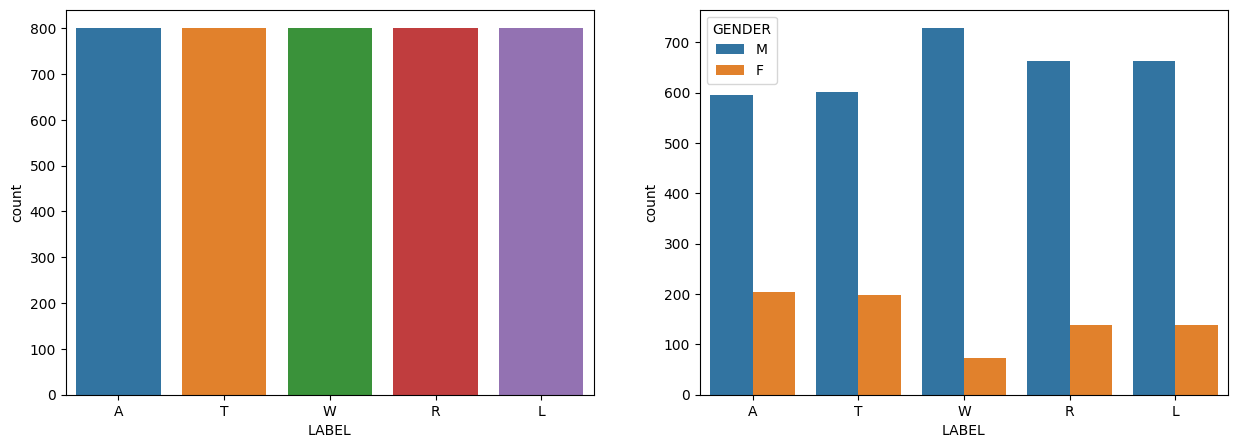

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(ax=axes[0], data = df, x = 'LABEL', hue = 'LABEL')
sns.countplot(ax=axes[1], data = df, x = 'LABEL', hue = 'GENDER')

In [ ]:
df['LABEL'].value_counts()

LABEL
A    800
T    800
W    800
R    800
L    800
Name: count, dtype: int64

From the plots above, it is clearly evident that there is a huge imbalance of the gender category. We won't train the model using that category and hence we can drop it. The labels are perfectly balanced, so we will continue use it without any changes.

In [ ]:
df.drop(columns = 'GENDER',inplace=True)
df.head()

,IMAGE PATH,IMAGE NAME,LABEL
0,dataset/f1021_06.png,f1021_06.png,A
1,dataset/s1001_05.png,s1001_05.png,T
2,dataset/s0986_08.png,s0986_08.png,W
3,dataset/f1364_05.png,f1364_05.png,R
4,dataset/s0729_04.png,s0729_04.png,A


Mapping the classes to an integer

In [ ]:
classes = list(np.unique(labels))
print(classes)
map_classes = dict(zip(classes, [t for t in range(len(classes))]))
print(map_classes)
df['MAPPED LABELS'] = [map_classes[i] for i in df['LABEL']]
df = df.sample(frac = 1)
df.to_csv('dataset.csv')
df.head()

['A', 'L', 'R', 'T', 'W']
{'A': 0, 'L': 1, 'R': 2, 'T': 3, 'W': 4}


,IMAGE PATH,IMAGE NAME,LABEL,MAPPED LABELS
328,dataset/s1750_01.png,s1750_01.png,W,4
1122,dataset/f1552_04.png,f1552_04.png,R,2
2417,dataset/s0450_10.png,s0450_10.png,A,0
3681,dataset/f1566_05.png,f1566_05.png,A,0
603,dataset/f1536_02.png,f1536_02.png,T,3


In [ ]:
df['MAPPED LABELS'] = [map_classes[i] for i in df['LABEL']]
df = df.sample(frac = 1)
df.to_csv('dataset.csv')
df.head()

,IMAGE PATH,IMAGE NAME,LABEL,MAPPED LABELS
1378,dataset/s1501_06.png,s1501_06.png,L,1
877,dataset/f1598_06.png,f1598_06.png,A,0
2274,dataset/s1220_02.png,s1220_02.png,T,3
1510,dataset/f0528_03.png,f0528_03.png,R,2
1086,dataset/f0689_03.png,f0689_03.png,R,2


Plotting one image from each of the different classes

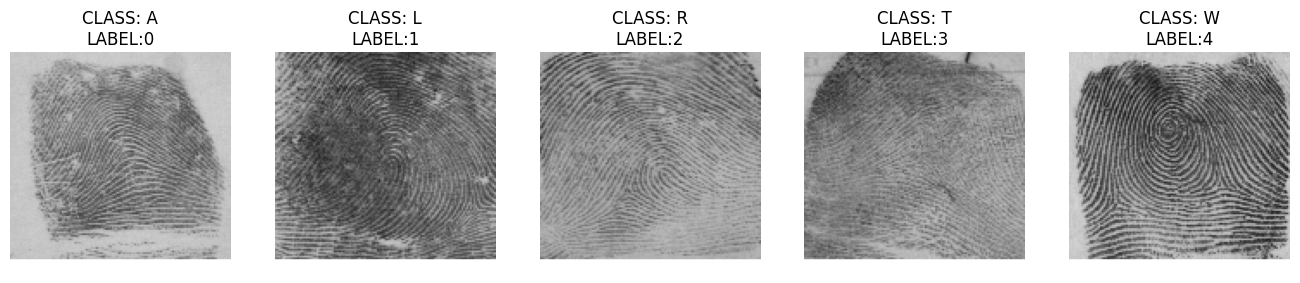

In [ ]:
dim = len(classes)
fig,axes = plt.subplots(1,dim)
fig.subplots_adjust(0,0,2,2)
for idx, i in enumerate(classes):
    dum = df[df['LABEL'] == i]
    random_num = random.choice(dum.index)
    label = df.loc[random_num]['LABEL']
    axes[idx].imshow(cv2.imread(df.loc[random_num]['IMAGE PATH']))
    axes[idx].set_title("CLASS: "+label +"\n" +  "LABEL:"+str(map_classes[label]))
    axes[idx].axis('off')

Checking if the images are grayscale

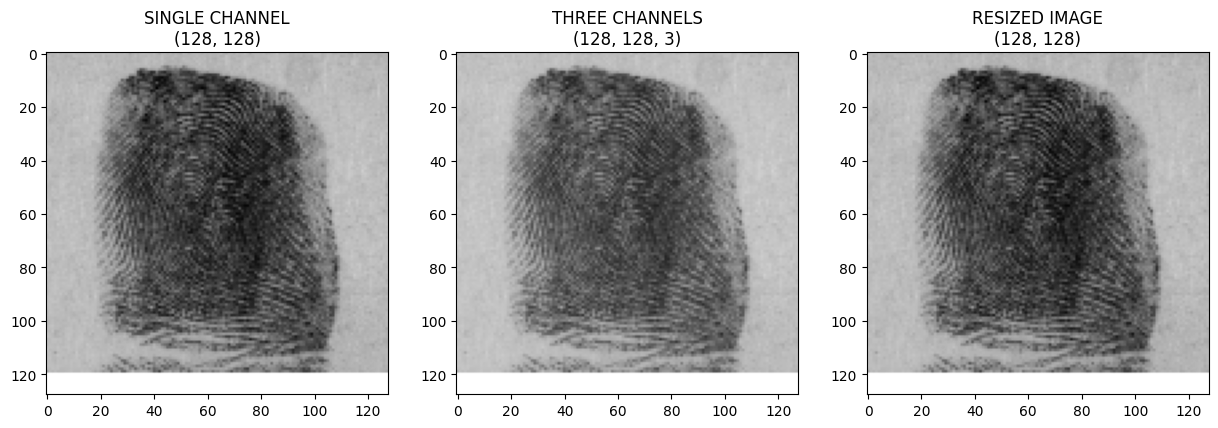

In [ ]:
random_number = random.randint(0,len(df))
img_path = df.loc[random_number]['IMAGE PATH']
gray_img = cv2.imread(img_path,0)
color_img = cv2.imread(img_path)
resized_img = cv2.resize(cv2.imread(img_path,0), (128,128)) #Resized Grayscale image

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].set_title('SINGLE CHANNEL\n'+ str(gray_img.shape))
axes[0].imshow(gray_img, cmap='gray')
axes[1].set_title('THREE CHANNELS\n'+ str(color_img.shape))
axes[1].imshow(color_img)
axes[2].set_title('RESIZED IMAGE\n'+ str(resized_img.shape))
axes[2].imshow(resized_img, cmap='gray')

The images that will be used is of the size (128,128). Now we can proceed towards building a model



Data Preparation

In [ ]:
X_data = df['IMAGE PATH']
y_data = df['MAPPED LABELS']
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, shuffle=True, test_size=0.01,stratify=y_data)
#Creating numpy arrays of images
X = []
y = []
for i in X_train:
    X.append(cv2.imread(i))
for i in y_train:
    y.append(i)
X = np.array(X)
y = np.array(y)
# Converting the labels vector to one-hot format
y = keras.utils.to_categorical(y, 5)

In [ ]:
print(f"Total number of Images: {len(X_data)}")
print(f"Number of Training Images: {len(X_train)}")
print(f"Number of Test Images: {len(X_test)}") # Saving a small number of images for model testing|
print(f"Shape of Images: {X[0].shape}") #Printing the shape of Images

Total number of Images: 4000
Number of Training Images: 3960
Number of Test Images: 40
Shape of Images: (128, 128, 3)


Model Architecture

In [ ]:
model = keras.Sequential(
    [
        layers.Conv2D(32, input_shape=(128,128,3),padding="same",kernel_size=(3, 3), activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(32, kernel_size=(3, 3), padding="same",activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3), padding="same",activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3),padding="same",activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, kernel_size=(3, 3),padding="same",activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, kernel_size=(3, 3),padding="same",activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(5, activation="softmax",kernel_regularizer='l1_l2'),
    ]
)

Checking the model parameters

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 64, 64, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 32)        9248      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 32, 32, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 64)        18496     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 64)        0

Train data

In [ ]:
#Hyperparameters
LOSS = 'categorical_crossentropy'
OPTIMIZER = 'adam'
BATCH_SIZE = 64
EPOCHS = 20

In [ ]:
model.compile(loss=LOSS, optimizer=OPTIMIZER, metrics=['accuracy'])

history=model.fit(x=X, y=y, batch_size=BATCH_SIZE, epochs=EPOCHS, validation_split=0.2)

Epoch 1/20
50/50 [==============================] - 102s 2s/step - loss: 4.6143 - accuracy: 0.2184 - val_loss: 2.9366 - val_accuracy: 0.2096
Epoch 2/20
50/50 [==============================] - 94s 2s/step - loss: 2.8502 - accuracy: 0.2693 - val_loss: 2.7205 - val_accuracy: 0.3497
Epoch 3/20
50/50 [==============================] - 93s 2s/step - loss: 2.5381 - accuracy: 0.4164 - val_loss: 2.3755 - val_accuracy: 0.4962
Epoch 4/20
50/50 [==============================] - 96s 2s/step - loss: 2.1277 - accuracy: 0.5597 - val_loss: 1.8994 - val_accuracy: 0.6439
Epoch 5/20
50/50 [==============================] - 97s 2s/step - loss: 1.9034 - accuracy: 0.6199 - val_loss: 1.7238 - val_accuracy: 0.6806
Epoch 6/20
50/50 [==============================] - 92s 2s/step - loss: 1.7235 - accuracy: 0.6616 - val_loss: 1.6156 - val_accuracy: 0.7222
Epoch 7/20
50/50 [==============================] - 104s 2s/step - loss: 1.5581 - accuracy: 0.7080 - val_loss: 1.5033 - val_accuracy: 0.7033
Epoch 8/20
50/50 [

Plotting Loss and Accuracy graphs

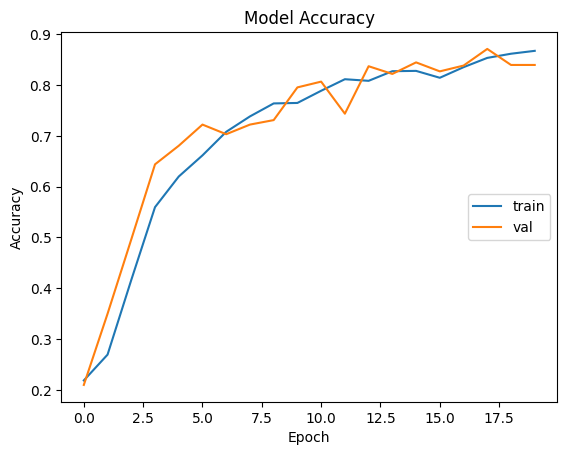

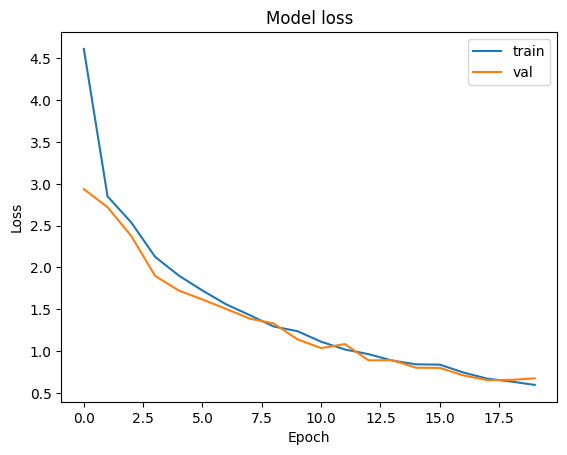

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='center right')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

Preparing data for testing

In [ ]:
test_X = []
for i in X_test:
    im = cv2.imread(i)
    im = np.reshape(im, (1,128,128,3))
    test_X.append(im)
test_X = np.array(test_X)

Plotting the predictions for the test images

1/1 [==============================] - 0s 31ms/step


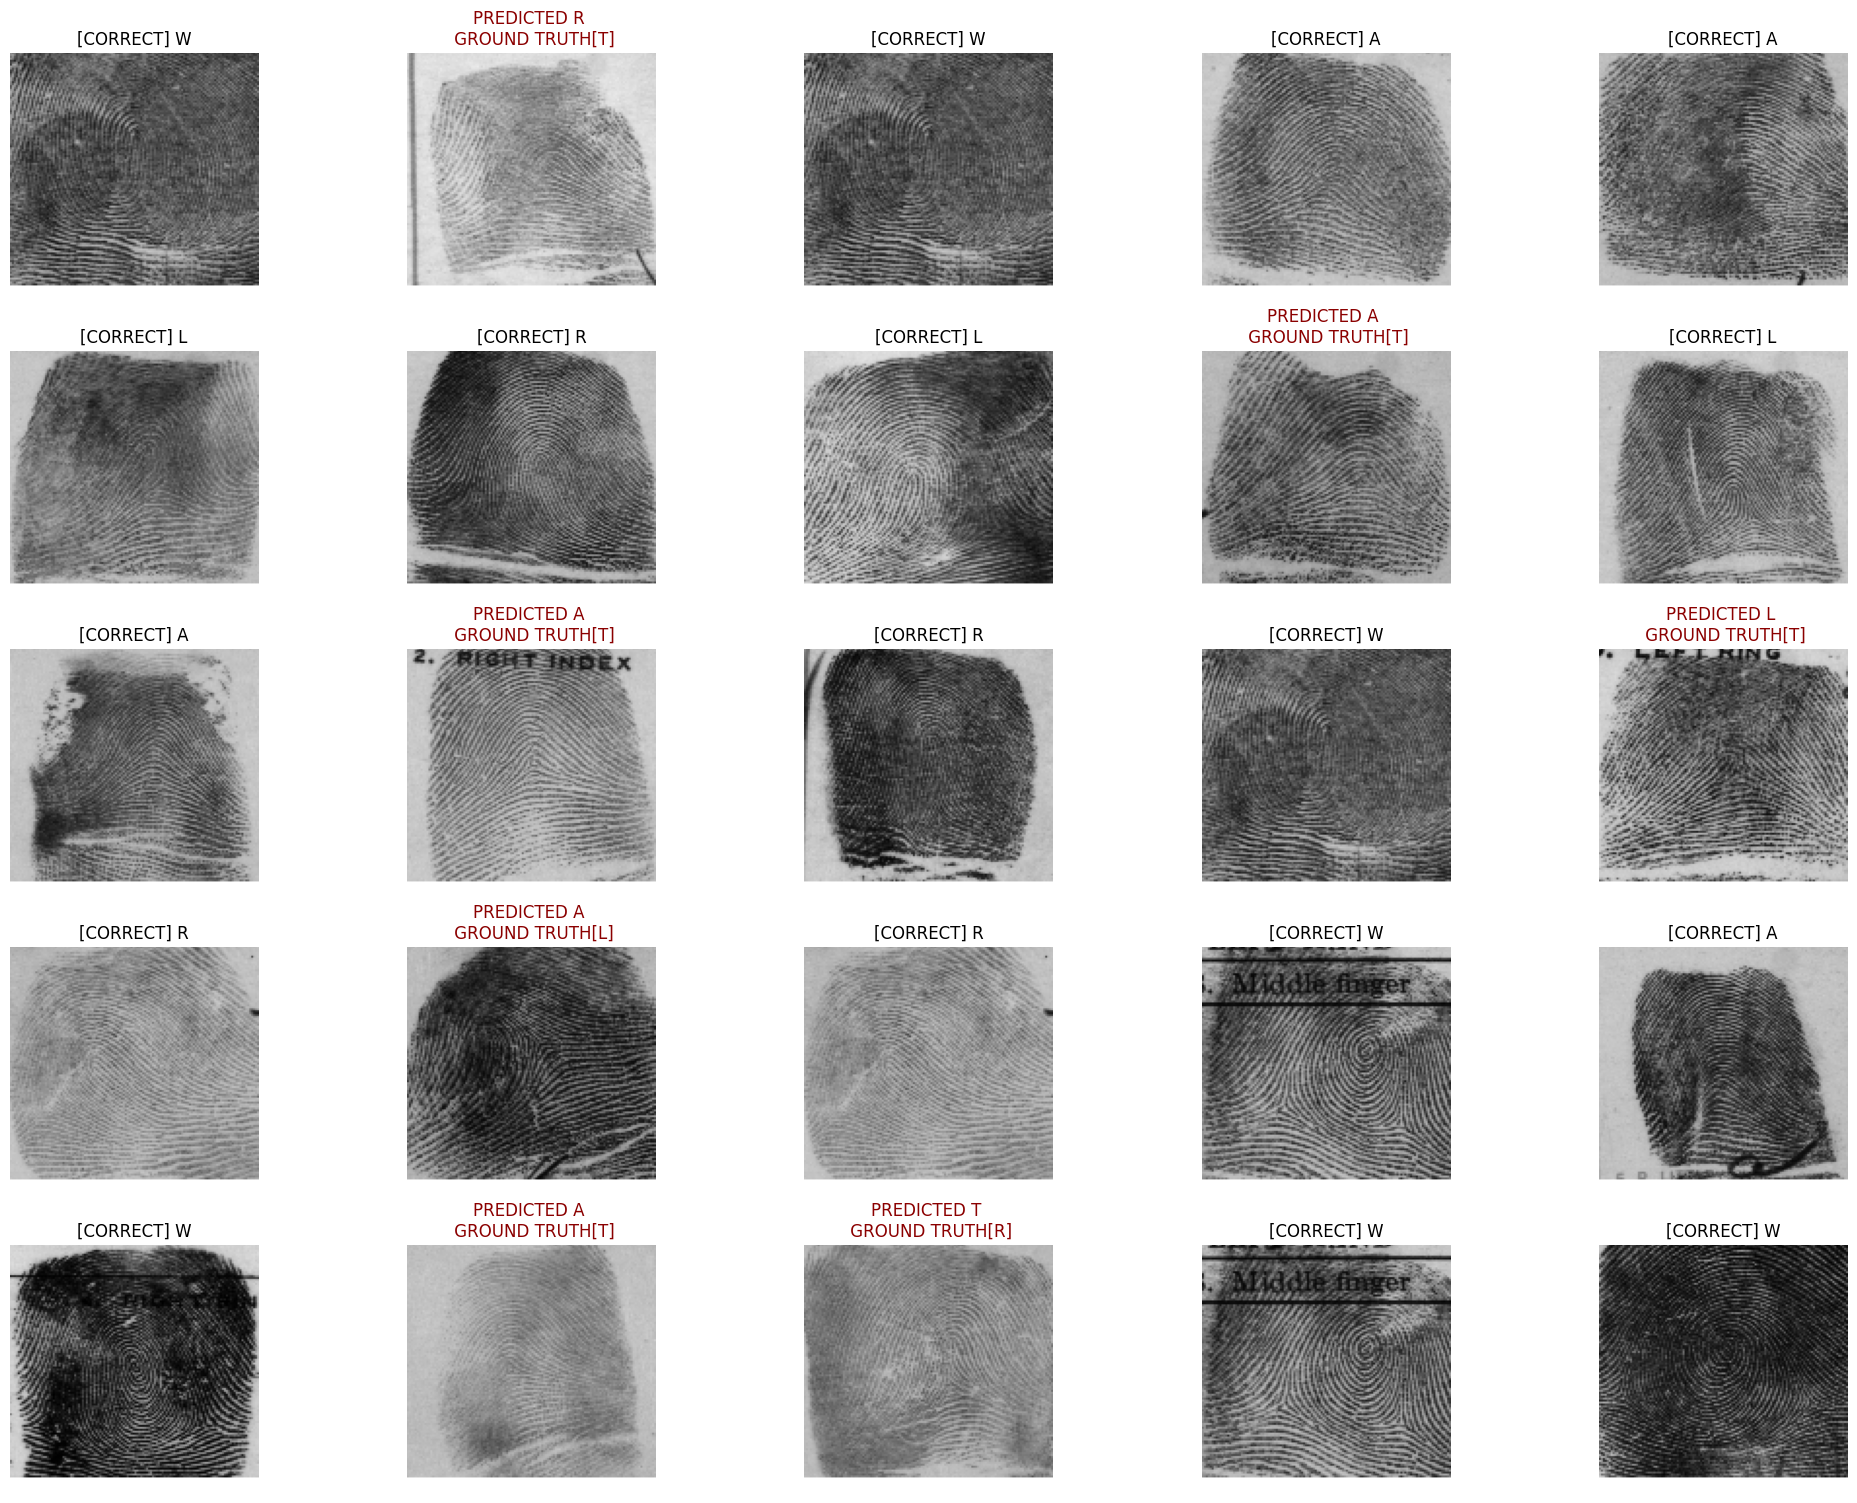

In [ ]:
fig,axes = plt.subplots(5,5)
fig.subplots_adjust(0,0,3,3)
for i in range(0,5,1):
    for j in range(0,5,1):
        num = random.randint(0,len(test_X)-1)
        display_image = test_X[num].squeeze(0)
        image = test_X[num]
        predicted_prob = model.predict(image)
        predicted_class = np.argmax(predicted_prob)
        ground_truth =classes[y_test.iloc[num]]
        axes[i,j].imshow(display_image)
        axes[i,j].imshow(display_image)
        if(classes[predicted_class] != classes[y_test.iloc[num]]):
            t = 'PREDICTED {} \n GROUND TRUTH[{}]'.format(classes[predicted_class], classes[y_test.iloc[num]])
            axes[i,j].set_title(t, fontdict={'color': 'darkred'})
        else:
            t = '[CORRECT] {}'.format(classes[predicted_class])
            axes[i,j].set_title(t)
        axes[i,j].axis('off')

Saving the model

In [ ]:
#Saving the model
model.save('fingerprint.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
